In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
trainsets = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

testsets = datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor())

In [3]:
class_names = trainsets.classes  #label
print(class_names)

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [4]:
print(trainsets.data.shape)
print(trainsets.targets.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])


In [5]:
print(testsets.data.shape)
print(testsets.targets.shape)

torch.Size([10000, 28, 28])
torch.Size([10000])


In [6]:
#Hyper parameter
BATCH_SIZE = 64
EPOCHS = 10

In [7]:
#Dataloader  use .utils & DataLoader
train_loader = torch.utils.data.DataLoader(dataset=trainsets, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=testsets, batch_size=BATCH_SIZE, shuffle=True)

In [8]:
#check size
images, labels = next(iter(test_loader))
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [9]:
#(H, W, C) to (C, H, W) [pytoch form] with transpose((1, 2, 0))
#function to show images in one Batch
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = inp * std +mean
    inp = np.clip(inp, 0, 1)  #map to 0-1
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.01)

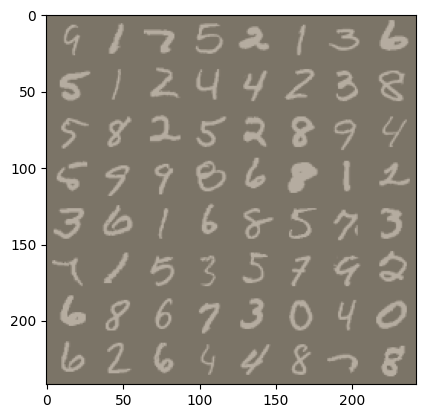

In [10]:
out = torchvision.utils.make_grid(images)  #网格
imshow(out)

In [11]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

#RNN
class RNN_Model(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(RNN_Model, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.rnn = nn.RNN(input_dim, hidden_dim, layer_dim, batch_first=True, nonlinearity='relu')
        #full connection
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        #(layer, batch, hidden)
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).requires_grad_().to(device)

        #split to avoid explode
        out, hn = self.rnn(x, h0.detach())
        out = self.fc(out[:,-1,])  #last hidden state
        return out

In [12]:
input_dim = 28
hidden_dim = 128
layer_dim = 2  #RNN layer
output_dim = 10

model = RNN_Model(input_dim, hidden_dim, layer_dim, output_dim).to(device)

In [13]:
criterion = nn.CrossEntropyLoss()

learning_rate = 0.025
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [14]:
length = len(list(model.parameters()))
print(length)

for i in range(length):
    print('parameters: %d' %(i+1))
    print(list(model.parameters())[i].size())

10
parameters: 1
torch.Size([128, 28])
parameters: 2
torch.Size([128, 128])
parameters: 3
torch.Size([128])
parameters: 4
torch.Size([128])
parameters: 5
torch.Size([128, 128])
parameters: 6
torch.Size([128, 128])
parameters: 7
torch.Size([128])
parameters: 8
torch.Size([128])
parameters: 9
torch.Size([10, 128])
parameters: 10
torch.Size([10])


In [15]:
#Training
sequence_dim = 28
loss_list = []
accuracy_list = []
iteration_list = []

iter = 0
for epoch in range(EPOCHS):
    for i, (images, labels) in enumerate(train_loader):
        model.train()
        images = images.view(-1, sequence_dim, input_dim).requires_grad_().to(device)  #-1 keep batch_size the same
        labels = labels.to(device)
        optimizer.zero_grad()
        #forward
        outputs = model(images)
        loss = criterion(outputs, labels)
        #backward
        loss.backward()
        #renew
        optimizer.step()
        iter += 1

        if iter % 500 ==0:
            model.eval()
            correct = 0.0
            total = 0.0
            for images, labels in test_loader:
                images = images.view(-1, sequence_dim, input_dim).to(device)
                labels = labels.to(device)
                outputs = model(images)
                predict = torch.max(outputs.data, 1)[1]
                total += labels.size(0)
                correct += (predict == labels).sum()
            accuracy = correct / total *100

            loss_list.append(loss.data)
            accuracy_list.append(accuracy)
            iteration_list.append(iter)

            print('loop : {}, loss : {}, accuracy : {}'.format(iter, loss.item(), accuracy))


loop : 500, loss : 2.299849510192871, accuracy : 15.60999870300293
loop : 1000, loss : 1.8070776462554932, accuracy : 30.459999084472656
loop : 1500, loss : 0.625285804271698, accuracy : 73.82999420166016
loop : 2000, loss : 0.41746458411216736, accuracy : 85.18999481201172
loop : 2500, loss : 0.4963432252407074, accuracy : 89.25
loop : 3000, loss : 0.22073441743850708, accuracy : 92.30999755859375
loop : 3500, loss : 0.29518216848373413, accuracy : 93.63999938964844
loop : 4000, loss : 0.1081908568739891, accuracy : 95.15999603271484
loop : 4500, loss : 0.2869352698326111, accuracy : 94.50999450683594
loop : 5000, loss : 0.34360334277153015, accuracy : 92.75999450683594
loop : 5500, loss : 0.1356988549232483, accuracy : 96.94000244140625
loop : 6000, loss : 0.10282856971025467, accuracy : 96.62999725341797
loop : 6500, loss : 0.156539186835289, accuracy : 96.2300033569336
loop : 7000, loss : 0.0523311011493206, accuracy : 97.25999450683594
loop : 7500, loss : 0.17681197822093964, accu

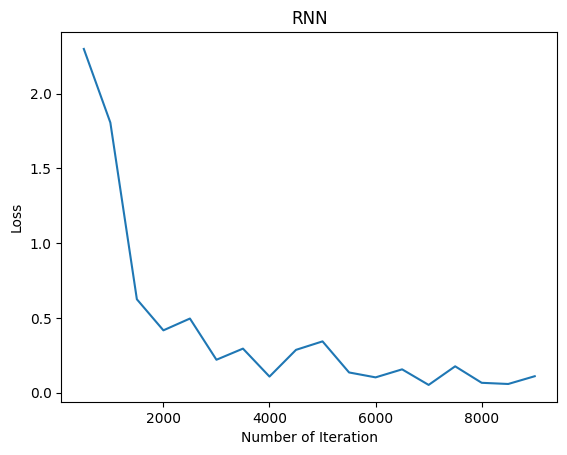

In [24]:
#data on cuda cant be used by plt
iteration_list_cpu = torch.tensor(iteration_list, device='cpu')
loss_list_cpu = torch.tensor(loss_list, device='cpu')

plt.plot(iteration_list_cpu, loss_list_cpu)
plt.xlabel('Number of Iteration')
plt.ylabel('Loss')
plt.title('RNN')
plt.show()

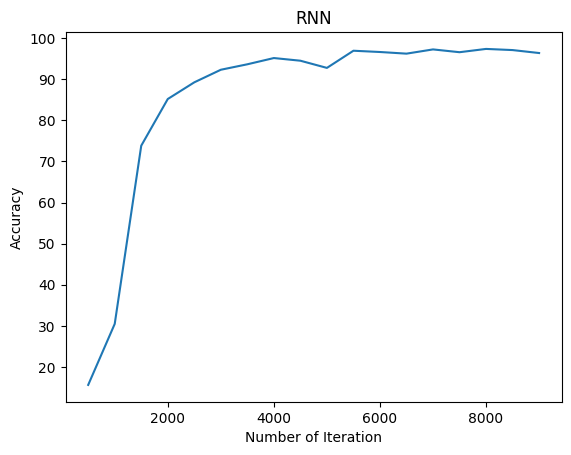

In [26]:
accuracy_list_cpu = torch.tensor(accuracy_list, device='cpu')

plt.plot(iteration_list_cpu, accuracy_list_cpu)
plt.xlabel('Number of Iteration')
plt.ylabel('Accuracy')
plt.title("RNN")
plt.show()

In [32]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

#RNN
class LSTM_Model(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(LSTM_Model, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True)
        #full connection
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        #(layer, batch, hidden)
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).requires_grad_().to(device)
        c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).requires_grad_().to(device)


        #split to avoid explode
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:,-1,])  #last hidden state
        return out

In [33]:
input_dim = 28
hidden_dim = 128
layer_dim = 2  #RNN layer
output_dim = 10

model = LSTM_Model(input_dim, hidden_dim, layer_dim, output_dim).to(device)

In [34]:
length = len(list(model.parameters()))
print(length)

for i in range(length):
    print('parameters: %d' %(i+1))
    print(list(model.parameters())[i].size())

10
parameters: 1
torch.Size([512, 28])
parameters: 2
torch.Size([512, 128])
parameters: 3
torch.Size([512])
parameters: 4
torch.Size([512])
parameters: 5
torch.Size([512, 128])
parameters: 6
torch.Size([512, 128])
parameters: 7
torch.Size([512])
parameters: 8
torch.Size([512])
parameters: 9
torch.Size([10, 128])
parameters: 10
torch.Size([10])


In [35]:
criterion = nn.CrossEntropyLoss()

learning_rate = 0.025
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [36]:
#Training
sequence_dim = 28
loss_list = []
accuracy_list = []
iteration_list = []

iter = 0
for epoch in range(EPOCHS):
    for i, (images, labels) in enumerate(train_loader):
        model.train()
        images = images.view(-1, sequence_dim, input_dim).requires_grad_().to(device)  #-1 keep batch_size the same
        labels = labels.to(device)
        optimizer.zero_grad()
        #forward
        outputs = model(images)
        loss = criterion(outputs, labels)
        #backward
        loss.backward()
        #renew
        optimizer.step()
        iter += 1

        if iter % 500 ==0:
            model.eval()
            correct = 0.0
            total = 0.0
            for images, labels in test_loader:
                images = images.view(-1, sequence_dim, input_dim).to(device)
                labels = labels.to(device)
                outputs = model(images)
                predict = torch.max(outputs.data, 1)[1]
                total += labels.size(0)
                correct += (predict == labels).sum()
            accuracy = correct / total *100

            loss_list.append(loss.data)
            accuracy_list.append(accuracy)
            iteration_list.append(iter)

            print('loop : {}, loss : {}, accuracy : {}'.format(iter, loss.item(), accuracy))


loop : 500, loss : 2.305459976196289, accuracy : 11.350000381469727
loop : 1000, loss : 2.306874990463257, accuracy : 11.350000381469727
loop : 1500, loss : 2.3062546253204346, accuracy : 11.350000381469727
loop : 2000, loss : 2.2983837127685547, accuracy : 11.350000381469727
loop : 2500, loss : 2.282724618911743, accuracy : 11.930000305175781
loop : 3000, loss : 2.282392978668213, accuracy : 12.549999237060547
loop : 3500, loss : 2.2519516944885254, accuracy : 22.09000015258789
loop : 4000, loss : 1.9299451112747192, accuracy : 25.799999237060547
loop : 4500, loss : 1.66450834274292, accuracy : 41.380001068115234
loop : 5000, loss : 1.0388660430908203, accuracy : 65.2300033569336
loop : 5500, loss : 0.7812501192092896, accuracy : 74.68000030517578
loop : 6000, loss : 0.6544312238693237, accuracy : 81.2199935913086
loop : 6500, loss : 0.34026575088500977, accuracy : 85.38999938964844
loop : 7000, loss : 0.5609630346298218, accuracy : 88.23999786376953
loop : 7500, loss : 0.334278047084

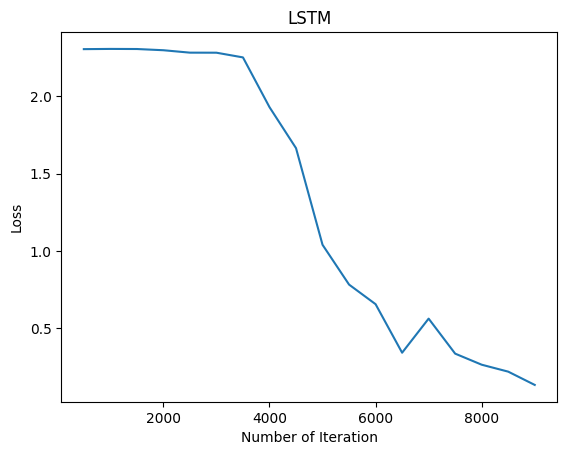

In [37]:
#data on cuda cant be used by plt
iteration_list_cpu = torch.tensor(iteration_list, device='cpu')
loss_list_cpu = torch.tensor(loss_list, device='cpu')

plt.plot(iteration_list_cpu, loss_list_cpu)
plt.xlabel('Number of Iteration')
plt.ylabel('Loss')
plt.title('LSTM')
plt.show()

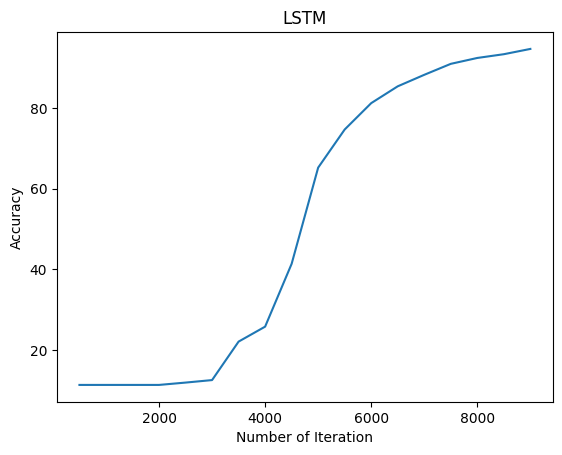

In [38]:
accuracy_list_cpu = torch.tensor(accuracy_list, device='cpu')

plt.plot(iteration_list_cpu, accuracy_list_cpu)
plt.xlabel('Number of Iteration')
plt.ylabel('Accuracy')
plt.title("LSTM")
plt.show()